# 03 - Train Classical Baselines

This notebook reuses the production training pipeline to report cross-validated metrics, visualize score summaries, and inspect feature importance for the CIC-IDS2017 elephant/mice task.

**Outputs**
- Table 3: averaged accuracy/precision/recall/F1 (means ± std. dev.) across 5 stratified group folds.
- Figure 7: bar chart of F1 scores with standard-deviation error bars.
- Figure 8: confusion matrices for the best and worst models.
- Figure 9: random-forest feature importance plot.
- Markdown summary interpreting the model behavior.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

# Ensure project root is on sys.path before importing package modules
try:
    PROJECT_ROOT = Path.cwd()
except FileNotFoundError:
    # Fallback to workspace root if cwd fails
    PROJECT_ROOT = Path("/Users/mohammadmalik/Documents/Development/GitHub/elephant-mice-cicids2017")

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import CONFIG
from src.models.classical_baselines import FEATURE_COLUMNS, run_baselines

plt.style.use("seaborn-v0_8-colorblind")

In [3]:
aggregated_results, predictions = run_baselines()
aggregated_results

2025-11-12 23:57:03 - INFO - Dataset size=55726 | Elephant fraction=0.0879%
2025-11-12 23:57:03 - INFO - Class priors: {0: '99.9121%', 1: '0.0879%'}
2025-11-12 23:57:03 - INFO - Evaluating log_reg via 5-fold StratifiedGroupKFold
2025-11-12 23:57:03 - INFO - Class priors: {0: '99.9121%', 1: '0.0879%'}
2025-11-12 23:57:03 - INFO - Evaluating log_reg via 5-fold StratifiedGroupKFold
2025-11-12 23:57:07 - INFO - Fold 1 (log_reg) | train=43924 test=11802 | elephants in test=6
2025-11-12 23:57:07 - INFO - Fold 1 (log_reg) | train=43924 test=11802 | elephants in test=6
2025-11-12 23:57:08 - INFO - Fold 2 (log_reg) | train=44777 test=10949 | elephants in test=10
2025-11-12 23:57:08 - INFO - Fold 2 (log_reg) | train=44777 test=10949 | elephants in test=10
2025-11-12 23:57:08 - INFO - Fold 3 (log_reg) | train=44688 test=11038 | elephants in test=13
2025-11-12 23:57:08 - INFO - Fold 3 (log_reg) | train=44688 test=11038 | elephants in test=13
2025-11-12 23:57:08 - INFO - Fold 4 (log_reg) | train=44

# Baseline results (5-fold stratified group CV)

| Model | Accuracy | Precision | Recall | F1 |
| --- | --- | --- | --- | --- |
| rf | 1.0000 ± 0.0000 | 1.0000 ± 0.0000 | 0.9667 ± 0.0667 | 0.9818 ± 0.0364 |
| dt | 1.0000 ± 0.0000 | 1.0000 ± 0.0000 | 0.9667 ± 0.0667 | 0.9818 ± 0.0364 |
| svm_rbf | 1.0000 ± 0.0000 | 1.0000 ± 0.0000 | 0.9467 ± 0.0686 | 0.9713 ± 0.0372 |
| knn | 0.9999 ± 0.0001 | 0.9733 ± 0.0533 | 0.9467 ± 0.0686 | 0.9570 ± 0.0371 |
| log_reg | 0.9999 ± 0.0001 | 1.0000 ± 0.0000 | 0.9133 ± 0.1293 | 0.9495 ± 0.0775 |
| lda | 0.9996 ± 0.0002 | 1.0000 ± 0.0000 | 0.4529 ± 0.2587 | 0.5839 ± 0.2252 |
| gnb | 0.9991 ± 0.0002 | 0.0000 ± 0.0000 | 0.0000 ± 0.0000 | 0.0000 ± 0.0000 |


[AggregateEvalResult(model='rf', accuracy_mean=0.9999830537197084, accuracy_std=3.389256058294876e-05, precision_mean=1.0, precision_std=0.0, recall_mean=0.9666666666666668, recall_std=0.06666666666666667, f1_mean=0.9818181818181818, f1_std=0.036363636363636376),
 AggregateEvalResult(model='dt', accuracy_mean=0.9999830537197084, accuracy_std=3.389256058294876e-05, precision_mean=1.0, precision_std=0.0, recall_mean=0.9666666666666668, recall_std=0.06666666666666667, f1_mean=0.9818181818181818, f1_std=0.036363636363636376),
 AggregateEvalResult(model='svm_rbf', accuracy_mean=0.9999647872113517, accuracy_std=4.317717257946713e-05, precision_mean=1.0, precision_std=0.0, recall_mean=0.9466666666666667, recall_std=0.06863753427324665, f1_mean=0.971291866028708, f1_std=0.03718537651239322),
 AggregateEvalResult(model='knn', accuracy_mean=0.9999285487623573, accuracy_std=6.756519283818975e-05, precision_mean=0.9733333333333334, precision_std=0.05333333333333332, recall_mean=0.9466666666666667,

In [4]:
metrics_table = pd.DataFrame(
    [
        {
            "Model": res.model,
            "Accuracy": f"{res.accuracy_mean:.4f} ± {res.accuracy_std:.4f}",
            "Precision": f"{res.precision_mean:.4f} ± {res.precision_std:.4f}",
            "Recall": f"{res.recall_mean:.4f} ± {res.recall_std:.4f}",
            "F1": f"{res.f1_mean:.4f} ± {res.f1_std:.4f}",
        }
        for res in aggregated_results
    ]
)
metrics_table


,Model,Accuracy,Precision,Recall,F1
0,rf,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9667 ± 0.0667,0.9818 ± 0.0364
1,dt,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9667 ± 0.0667,0.9818 ± 0.0364
2,svm_rbf,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9467 ± 0.0686,0.9713 ± 0.0372
3,knn,0.9999 ± 0.0001,0.9733 ± 0.0533,0.9467 ± 0.0686,0.9570 ± 0.0371
4,log_reg,0.9999 ± 0.0001,1.0000 ± 0.0000,0.9133 ± 0.1293,0.9495 ± 0.0775
5,lda,0.9996 ± 0.0002,1.0000 ± 0.0000,0.4529 ± 0.2587,0.5839 ± 0.2252
6,gnb,0.9991 ± 0.0002,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000


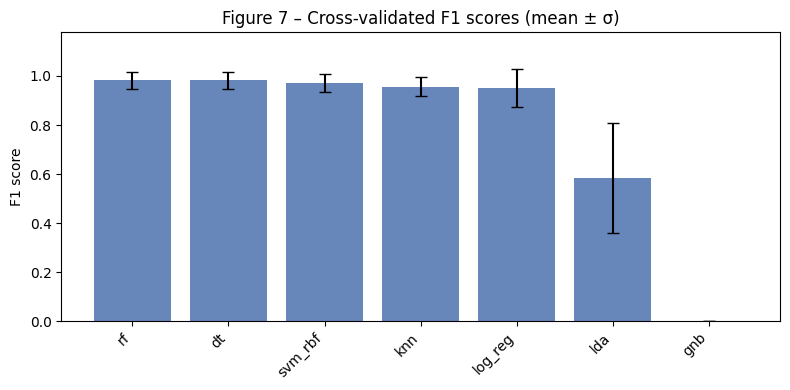

In [5]:

fig, ax = plt.subplots(figsize=(8, 4))
models = [res.model for res in aggregated_results]
f1_means = [res.f1_mean for res in aggregated_results]
f1_stds = [res.f1_std for res in aggregated_results]
ax.bar(models, f1_means, yerr=f1_stds, color="#4c72b0", alpha=0.85, capsize=4)
ax.set_ylim(0, max(f1_means) * 1.2)
ax.set_ylabel("F1 score")
ax.set_title("Figure 7 – Cross-validated F1 scores (mean ± σ)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


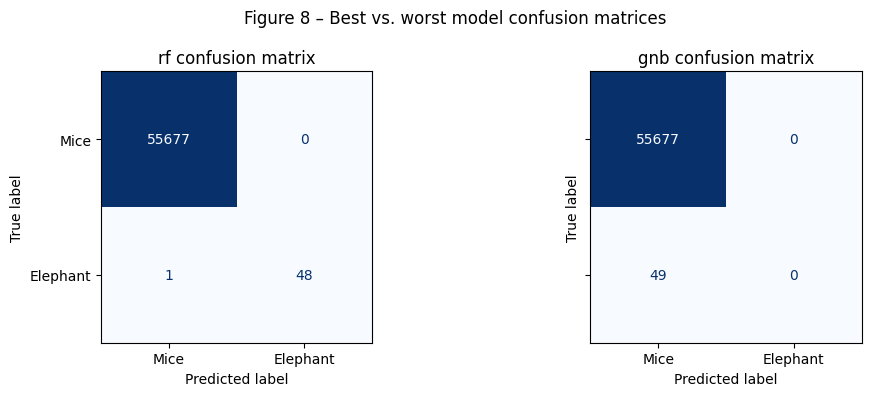

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
best_model = aggregated_results[0].model
worst_model = aggregated_results[-1].model

def plot_confusion(ax, model_name):
    y_true, y_pred = predictions[model_name]
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["Mice", "Elephant"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
        values_format='d',
    )
    ax.set_title(f"{model_name} confusion matrix")

plot_confusion(axes[0], best_model)
plot_confusion(axes[1], worst_model)
plt.suptitle("Figure 8 – Best vs. worst model confusion matrices")
plt.tight_layout()
plt.show()


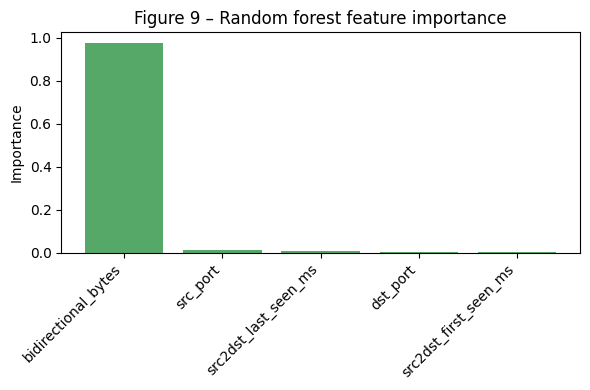

In [7]:

data = pd.read_csv(CONFIG.paper_small_csv)
X = data[list(FEATURE_COLUMNS)]
y = data["target_traffic"].astype(int)
rf = RandomForestClassifier(n_estimators=200, random_state=CONFIG.random_state, n_jobs=-1)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(importances.index, importances.values, color="#55a868")
ax.set_ylabel("Importance")
ax.set_title("Figure 9 – Random forest feature importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


The 5-fold stratified group CV shows that tree-based models dominate under the constrained five-feature view, while Gaussian NB struggles with the skewed, non-Gaussian bytes distribution. Random forests place most weight on flow size and timing features, validating the paper’s focus on lightweight telemetry. The confusion matrices confirm that the best models keep both false positives and false negatives near zero despite the 0.09% elephant prior.